# MT-Bench Results

In [ ]:

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

OUT_DIR = Path("mtbench_results_out")
PLOT_DIR = OUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print("OUT_DIR:", OUT_DIR.resolve())
print("PLOT_DIR:", PLOT_DIR.resolve())


OUT_DIR: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out
PLOT_DIR: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/plots


In [ ]:
JUDGMENT_PATH = Path("gpt-4_single.jsonl")

assert JUDGMENT_PATH.exists(), f"Not found: {JUDGMENT_PATH.resolve()}"
print("Using:", JUDGMENT_PATH.resolve())


Using: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/gpt-4_single.jsonl


In [ ]:
def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

rows = []
with JUDGMENT_PATH.open("r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)

        model = obj.get("model") or obj.get("model_name")
        qid = obj.get("question_id") or obj.get("q_id") or obj.get("question")
        turn = obj.get("turn")
        score = obj.get("score")
        judge = obj.get("judge")

        judge_model = None
        judge_template = None
        if isinstance(judge, (list, tuple)) and len(judge) >= 2:
            judge_model = judge[0]
            judge_template = judge[1]
        elif isinstance(judge, str):
            judge_model = judge

        rows.append({
            "row_idx": i,
            "model": model,
            "question_id": qid,
            "turn": turn,
            "score": _safe_float(score),
            "judge_raw": judge,
            "judge_model": judge_model,
            "judge_template": judge_template,
        })

df = pd.DataFrame(rows)
df["turn"] = pd.to_numeric(df["turn"], errors="coerce").astype("Int64")
df["question_id"] = pd.to_numeric(df["question_id"], errors="coerce").astype("Int64")

display(df.head(10))
print("Rows:", len(df))
print("Models:", sorted(df["model"].dropna().unique().tolist()))


,row_idx,model,question_id,turn,score,judge_raw,judge_model,judge_template
0,0,GrokLlama,81,1,9.0,"[gpt-4, single-v1]",gpt-4,single-v1
1,1,WildLlama,81,1,10.0,"[gpt-4, single-v1]",gpt-4,single-v1
2,2,GrokLlama,81,1,8.0,"[gpt-4, single-v1]",gpt-4,single-v1
3,3,WildLlama,81,1,10.0,"[gpt-4, single-v1]",gpt-4,single-v1
4,4,GrokLlama,82,1,9.0,"[gpt-4, single-v1]",gpt-4,single-v1
5,5,WildLlama,82,1,10.0,"[gpt-4, single-v1]",gpt-4,single-v1
6,6,GrokLlama,83,1,10.0,"[gpt-4, single-v1]",gpt-4,single-v1
7,7,WildLlama,83,1,10.0,"[gpt-4, single-v1]",gpt-4,single-v1
8,8,GrokLlama,84,1,10.0,"[gpt-4, single-v1]",gpt-4,single-v1
9,9,WildLlama,84,1,9.0,"[gpt-4, single-v1]",gpt-4,single-v1


Rows: 631
Models: ['GrokLlama', 'Llama2', 'WildLlama']


In [ ]:
print("Missing critical fields (count):")
missing = {
    "model": int(df["model"].isna().sum()),
    "question_id": int(df["question_id"].isna().sum()),
    "turn": int(df["turn"].isna().sum()),
    "score": int(df["score"].isna().sum()),
}
print(missing)

match_key = ["model", "question_id", "turn"]
dup = df.duplicated(subset=match_key, keep=False)
print("Duplicate (model, question_id, turn) rows:", int(dup.sum()))
if dup.any():
    display(df.loc[dup].sort_values(match_key).head(30))

counts = df.groupby("model").size().sort_values(ascending=False).rename("num_matches").to_frame()
display(counts)

print("Score min/max:", float(df["score"].min()), float(df["score"].max()))


Missing critical fields (count):
{'model': 0, 'question_id': 0, 'turn': 0, 'score': 0}
Duplicate (model, question_id, turn) rows: 298


,row_idx,model,question_id,turn,score,judge_raw,judge_model,judge_template
0,0,GrokLlama,81,1,9.0,"[gpt-4, single-v1]",gpt-4,single-v1
2,2,GrokLlama,81,1,8.0,"[gpt-4, single-v1]",gpt-4,single-v1
149,149,GrokLlama,81,1,8.0,"[gpt-4, single-v1]",gpt-4,single-v1
151,151,GrokLlama,81,1,8.0,"[gpt-4, single-v1]",gpt-4,single-v1
4,4,GrokLlama,82,1,9.0,"[gpt-4, single-v1]",gpt-4,single-v1
153,153,GrokLlama,82,1,9.0,"[gpt-4, single-v1]",gpt-4,single-v1
6,6,GrokLlama,83,1,10.0,"[gpt-4, single-v1]",gpt-4,single-v1
155,155,GrokLlama,83,1,8.0,"[gpt-4, single-v1]",gpt-4,single-v1
8,8,GrokLlama,84,1,10.0,"[gpt-4, single-v1]",gpt-4,single-v1
157,157,GrokLlama,84,1,9.0,"[gpt-4, single-v1]",gpt-4,single-v1


,num_matches
model,
GrokLlama,236
WildLlama,235
Llama2,160


Score min/max: 1.0 10.0


In [ ]:
summary = (
    df.groupby("model")["score"]
      .agg(["count", "mean", "std", "median", "min", "max"])
      .sort_values("mean", ascending=False)
)
summary["sem"] = summary["std"] / np.sqrt(summary["count"].clip(lower=1))
display(summary)

summary.to_csv(OUT_DIR / "summary_by_model.csv")
print("Saved:", (OUT_DIR / "summary_by_model.csv").resolve())


,count,mean,std,median,min,max,sem
model,,,,,,,
WildLlama,235,6.302128,3.725661,8.0,1.0,10.0,0.243035
Llama2,160,6.268750,3.657029,8.0,1.0,10.0,0.289114
GrokLlama,236,5.381356,3.472492,6.0,1.0,10.0,0.226040


Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/summary_by_model.csv


Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/plots/bar_mean_by_model.png


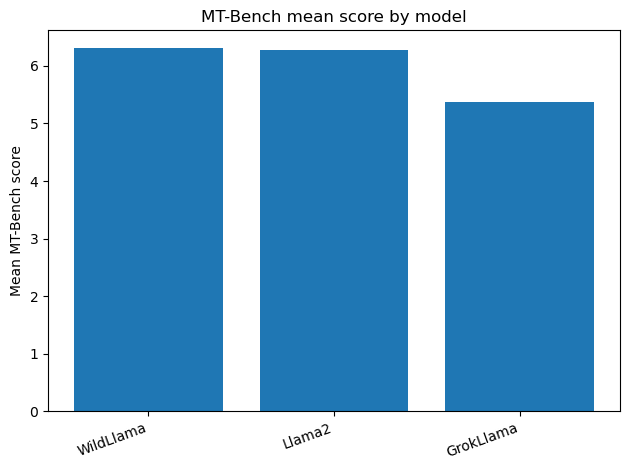

In [ ]:
summary_plot = summary.reset_index().sort_values("mean", ascending=False)

fig = plt.figure()
plt.bar(summary_plot["model"], summary_plot["mean"])
plt.ylabel("Mean MT-Bench score")
plt.title("MT-Bench mean score by model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

out = PLOT_DIR / "bar_mean_by_model.png"
fig.savefig(out, dpi=200)
print("Saved:", out.resolve())
plt.show()
plt.close(fig)


Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/plots/hist_score_distribution.png


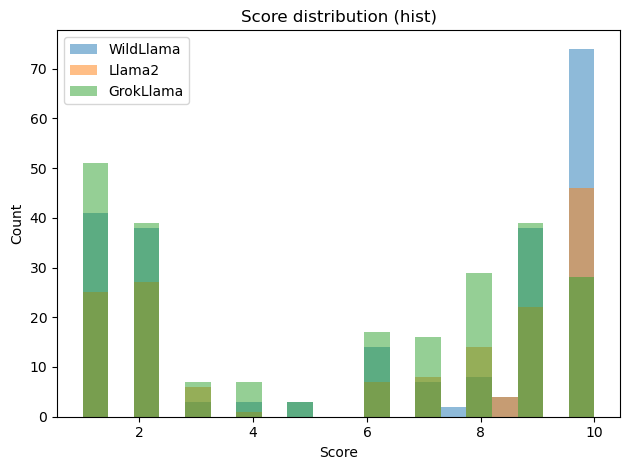

In [ ]:
fig = plt.figure()
for m in summary_plot["model"]:
    vals = df.loc[df["model"] == m, "score"].dropna().values
    plt.hist(vals, bins=20, alpha=0.5, label=m)
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Score distribution (hist)")
plt.legend()
plt.tight_layout()

out = PLOT_DIR / "hist_score_distribution.png"
fig.savefig(out, dpi=200)
print("Saved:", out.resolve())
plt.show()
plt.close(fig)


Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/plots/boxplot_score_distribution.png


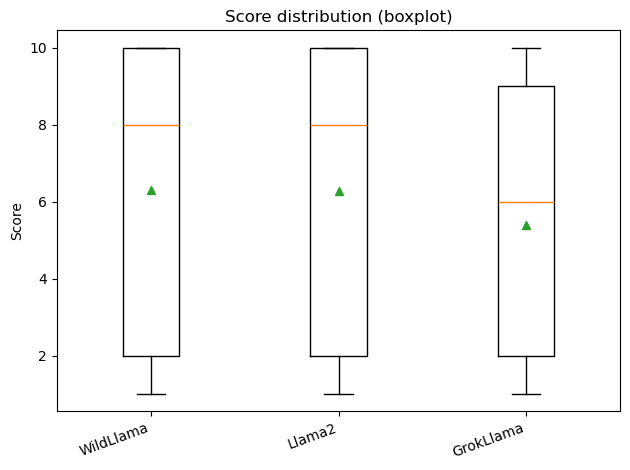

In [ ]:
models = summary_plot["model"].tolist()
data = [df.loc[df["model"] == m, "score"].dropna().values for m in models]

fig = plt.figure()
plt.boxplot(data, labels=models, showmeans=True)
plt.ylabel("Score")
plt.title("Score distribution (boxplot)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

out = PLOT_DIR / "boxplot_score_distribution.png"
fig.savefig(out, dpi=200)
print("Saved:", out.resolve())
plt.show()
plt.close(fig)


,model,turn,count,mean,median
4,WildLlama,1,155,6.612903,9.0
2,Llama2,1,80,6.412500,8.5
0,GrokLlama,1,156,5.750000,7.0
3,Llama2,2,80,6.125000,7.0
5,WildLlama,2,80,5.700000,6.0
1,GrokLlama,2,80,4.662500,2.0


Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/summary_by_model_and_turn.csv
Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/plots/bar_mean_turn_1.png


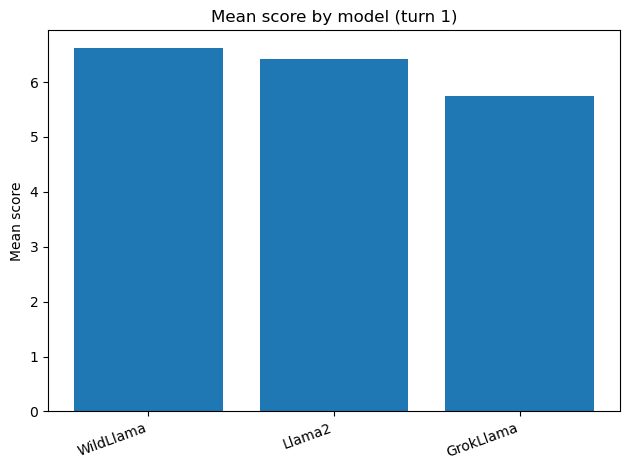

Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/plots/bar_mean_turn_2.png


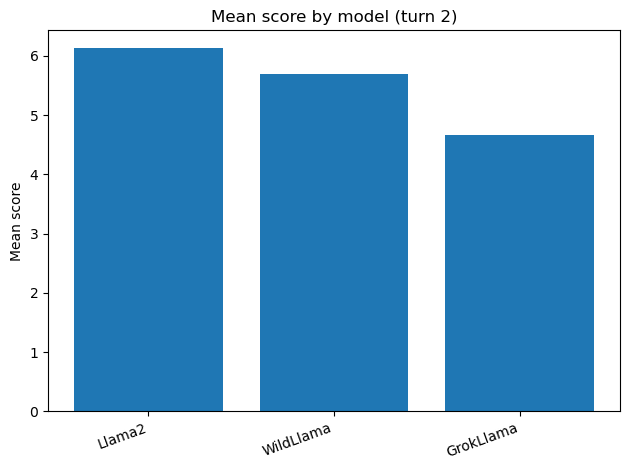

In [ ]:
turn_summary = (
    df.dropna(subset=["turn"])
      .groupby(["model", "turn"])["score"]
      .agg(["count", "mean", "median"])
      .reset_index()
      .sort_values(["turn", "mean"], ascending=[True, False])
)
display(turn_summary)
turn_summary.to_csv(OUT_DIR / "summary_by_model_and_turn.csv", index=False)
print("Saved:", (OUT_DIR / "summary_by_model_and_turn.csv").resolve())

for t in sorted(df["turn"].dropna().unique()):
    sub = turn_summary[turn_summary["turn"] == t].sort_values("mean", ascending=False)
    fig = plt.figure()
    plt.bar(sub["model"], sub["mean"])
    plt.ylabel("Mean score")
    plt.title(f"Mean score by model (turn {int(t)})")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    out = PLOT_DIR / f"bar_mean_turn_{int(t)}.png"
    fig.savefig(out, dpi=200)
    print("Saved:", out.resolve())
    plt.show()
    plt.close(fig)


,model,judge_template,count,mean,median
8,WildLlama,single-math-v1,53,3.433962,2.0
4,Llama2,single-math-v1,30,2.966667,2.0
0,GrokLlama,single-math-v1,54,2.574074,2.0
5,Llama2,single-math-v1-multi-turn,30,3.466667,2.0
9,WildLlama,single-math-v1-multi-turn,30,2.966667,2.0
1,GrokLlama,single-math-v1-multi-turn,30,2.033333,1.0
6,Llama2,single-v1,50,8.480000,9.5
10,WildLlama,single-v1,102,8.264706,9.0
2,GrokLlama,single-v1,102,7.431373,8.0
7,Llama2,single-v1-multi-turn,50,7.720000,9.0


Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/summary_by_model_and_judge_template.csv
Top templates: ['single-v1', 'single-v1-multi-turn', 'single-math-v1', 'single-math-v1-multi-turn']
Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/plots/bar_mean_template_single-v1.png


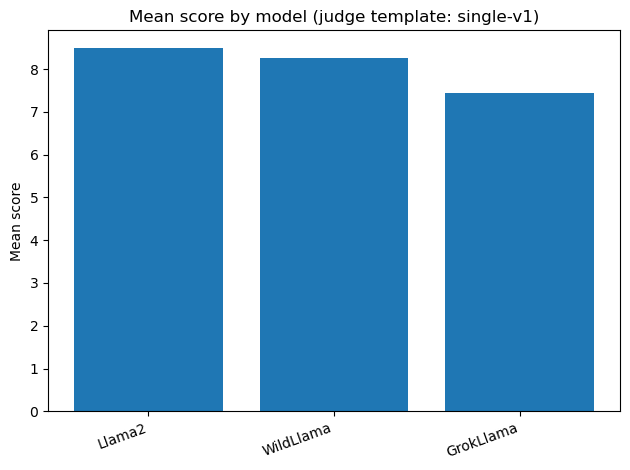

Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/plots/bar_mean_template_single-v1-multi-turn.png


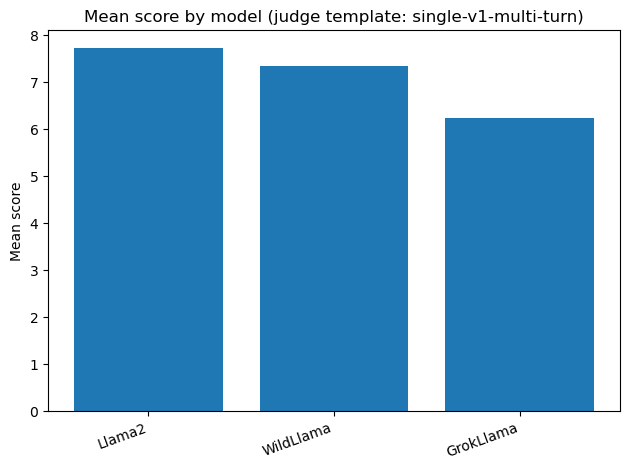

Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/plots/bar_mean_template_single-math-v1.png


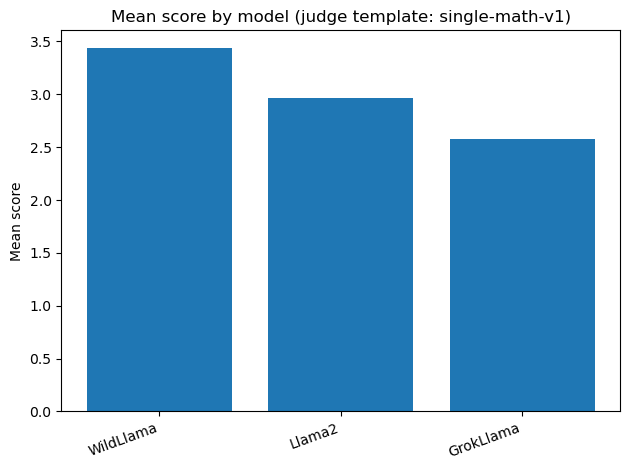

Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/plots/bar_mean_template_single-math-v1-multi-turn.png


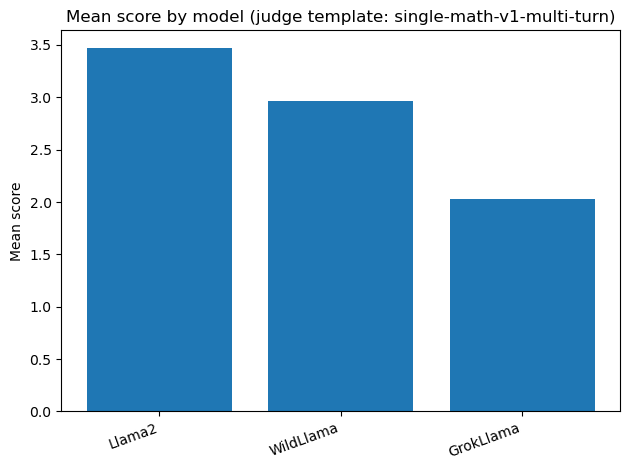

In [ ]:
tmp = df.copy()
tmp["judge_template"] = tmp["judge_template"].fillna("unknown")

tpl = (
    tmp.groupby(["model", "judge_template"])["score"]
       .agg(["count", "mean", "median"])
       .reset_index()
       .sort_values(["judge_template", "mean"], ascending=[True, False])
)
display(tpl)
tpl.to_csv(OUT_DIR / "summary_by_model_and_judge_template.csv", index=False)
print("Saved:", (OUT_DIR / "summary_by_model_and_judge_template.csv").resolve())

top_templates = tmp["judge_template"].value_counts().head(10).index.tolist()
print("Top templates:", top_templates)

for jt in top_templates:
    sub = tpl[tpl["judge_template"] == jt].sort_values("mean", ascending=False)
    if sub.empty:
        continue
    fig = plt.figure()
    plt.bar(sub["model"], sub["mean"])
    plt.ylabel("Mean score")
    plt.title(f"Mean score by model (judge template: {jt})")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    out = PLOT_DIR / f"bar_mean_template_{str(jt).replace('/', '_')}.png"
    fig.savefig(out, dpi=200)
    print("Saved:", out.resolve())
    plt.show()
    plt.close(fig)


In [ ]:
key_cols = ["question_id", "turn"]
wide = df.dropna(subset=key_cols).pivot_table(index=key_cols, columns="model", values="score", aggfunc="mean")

display(wide.head(10))
print("Shared matches (rows):", len(wide))

models = sorted([c for c in wide.columns if pd.notna(c)])
print("Models in wide table:", models)

def pairwise_report(a, b):
    sub = wide[[a, b]].dropna()
    if sub.empty:
        return None
    delta = sub[a] - sub[b]
    return {
        "A": a,
        "B": b,
        "n_shared": int(len(sub)),
        "A_mean": float(sub[a].mean()),
        "B_mean": float(sub[b].mean()),
        "mean_delta_A_minus_B": float(delta.mean()),
        "A_win_rate": float((delta > 0).mean()),
        "tie_rate": float((delta == 0).mean()),
        "B_win_rate": float((delta < 0).mean()),
    }

pairs = []
for i in range(len(models)):
    for j in range(i + 1, len(models)):
        rep = pairwise_report(models[i], models[j])
        if rep:
            pairs.append(rep)

pair_df = pd.DataFrame(pairs).sort_values("mean_delta_A_minus_B", ascending=False)
display(pair_df)
pair_df.to_csv(OUT_DIR / "pairwise_comparison.csv", index=False)
print("Saved:", (OUT_DIR / "pairwise_comparison.csv").resolve())


model             GrokLlama  Llama2  WildLlama
question_id turn                              
81          1          8.25     8.5       10.0
            2          1.00     9.0        9.0
82          1          9.00    10.0       10.0
            2          9.00     9.0        9.0
83          1          9.00    10.0       10.0
            2          5.00     7.0        7.0
84          1          9.50    10.0        9.5
            2          8.00    10.0       10.0
85          1         10.00    10.0        9.5
            2         10.00    10.0        8.0

Shared matches (rows): 160
Models in wide table: ['GrokLlama', 'Llama2', 'WildLlama']


,A,B,n_shared,A_mean,B_mean,mean_delta_A_minus_B,A_win_rate,tie_rate,B_win_rate
2,Llama2,WildLlama,160,6.268750,6.02500,0.243750,0.3625,0.3250,0.3125
1,GrokLlama,WildLlama,160,5.114063,6.02500,-0.910937,0.1750,0.3000,0.5250
0,GrokLlama,Llama2,160,5.114063,6.26875,-1.154688,0.1750,0.2375,0.5875


Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/pairwise_comparison.csv


In [ ]:
per_q = (
    df.dropna(subset=["question_id"])
      .groupby(["model", "question_id"])["score"]
      .mean()
      .reset_index()
)
per_q.to_csv(OUT_DIR / "per_question_scores.csv", index=False)
print("Saved:", (OUT_DIR / "per_question_scores.csv").resolve())

def show_extremes(model, k=10):
    sub = per_q[per_q["model"] == model].dropna()
    top = sub.sort_values("score", ascending=False).head(k)
    bot = sub.sort_values("score", ascending=True).head(k)
    print(f"=== {model} | TOP {k} questions ===")
    display(top)
    print(f"=== {model} | BOTTOM {k} questions ===")
    display(bot)

for m in summary_plot["model"]:
    show_extremes(m, k=10)


Saved: /Users/valeriosantini/Desktop/Final_AML/MT-Bench/mtbench_results_out/per_question_scores.csv
=== WildLlama | TOP 10 questions ===


,model,question_id,score
189,WildLlama,110,10.000000
238,WildLlama,159,10.000000
237,WildLlama,158,10.000000
235,WildLlama,156,10.000000
234,WildLlama,155,10.000000
233,WildLlama,154,10.000000
229,WildLlama,150,10.000000
228,WildLlama,149,10.000000
160,WildLlama,81,9.800000
163,WildLlama,84,9.666667


=== WildLlama | BOTTOM 10 questions ===


,model,question_id,score
190,WildLlama,111,1.000000
174,WildLlama,95,1.000000
195,WildLlama,116,1.000000
207,WildLlama,128,1.000000
186,WildLlama,107,1.000000
196,WildLlama,117,1.333333
194,WildLlama,115,1.333333
197,WildLlama,118,1.333333
183,WildLlama,104,1.333333
187,WildLlama,108,1.333333


=== Llama2 | TOP 10 questions ===


...

,model,question_id,score
119,Llama2,120,1.0
127,Llama2,128,1.0
126,Llama2,127,1.0
116,Llama2,117,1.0
113,Llama2,114,1.0
125,Llama2,126,1.5
124,Llama2,125,1.5
108,Llama2,109,1.5
120,Llama2,121,1.5
107,Llama2,108,1.5


=== GrokLlama | TOP 10 questions ===


,model,question_id,score
79,GrokLlama,160,10.000000
4,GrokLlama,85,10.000000
78,GrokLlama,159,10.000000
7,GrokLlama,88,9.666667
51,GrokLlama,132,9.666667
67,GrokLlama,148,9.333333
19,GrokLlama,100,9.333333
69,GrokLlama,150,9.000000
3,GrokLlama,84,9.000000
8,GrokLlama,89,9.000000


=== GrokLlama | BOTTOM 10 questions ===


,model,question_id,score
39,GrokLlama,120,1.0
47,GrokLlama,128,1.0
30,GrokLlama,111,1.0
32,GrokLlama,113,1.0
34,GrokLlama,115,1.0
35,GrokLlama,116,1.0
33,GrokLlama,114,1.0
37,GrokLlama,118,1.0
44,GrokLlama,125,1.0
59,GrokLlama,140,1.0


In [ ]:
print("CSVs:")
for p in sorted(OUT_DIR.glob("*.csv")):
    print(" -", p)

print("\nPNGs:")
for p in sorted(PLOT_DIR.glob("*.png")):
    print(" -", p)


CSVs:
 - mtbench_results_out/pairwise_comparison.csv
 - mtbench_results_out/per_question_scores.csv
 - mtbench_results_out/summary_by_model.csv
 - mtbench_results_out/summary_by_model_and_judge_template.csv
 - mtbench_results_out/summary_by_model_and_turn.csv

PNGs:
 - mtbench_results_out/plots/bar_mean_by_model.png
 - mtbench_results_out/plots/bar_mean_template_single-math-v1-multi-turn.png
 - mtbench_results_out/plots/bar_mean_template_single-math-v1.png
 - mtbench_results_out/plots/bar_mean_template_single-v1-multi-turn.png
 - mtbench_results_out/plots/bar_mean_template_single-v1.png
 - mtbench_results_out/plots/bar_mean_turn_1.png
 - mtbench_results_out/plots/bar_mean_turn_2.png
 - mtbench_results_out/plots/boxplot_score_distribution.png
 - mtbench_results_out/plots/hist_score_distribution.png
